In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
import torch

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

import warnings
warnings.filterwarnings("ignore")

In [4]:
from PINN import reader
from PINN import models

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# load

In [116]:
meahr_monocle = sc.read_h5ad("data/meahr_monocle.h5ad")
meahr_monocle_plot = meahr_monocle[meahr_monocle.obs.leiden!='9']

In [ ]:
celltype_colors =  ["#7C8DBE", "#BA7590", "#A1689E", "#7f7f7f", # FFF5D4",
                     "#C5D9ED", "#FFE7BD", "#F0AD8E", '#6F71A3']
palette = dict(zip(meahr_monocle.obs['celltype'].cat.categories,celltype_colors ))

meahr_monocle_plot.uns['celltype_colors'] = celltype_colors


<Axes: title={'center': 'scaled pseudotime'}, xlabel='UMAP1', ylabel='UMAP2'>

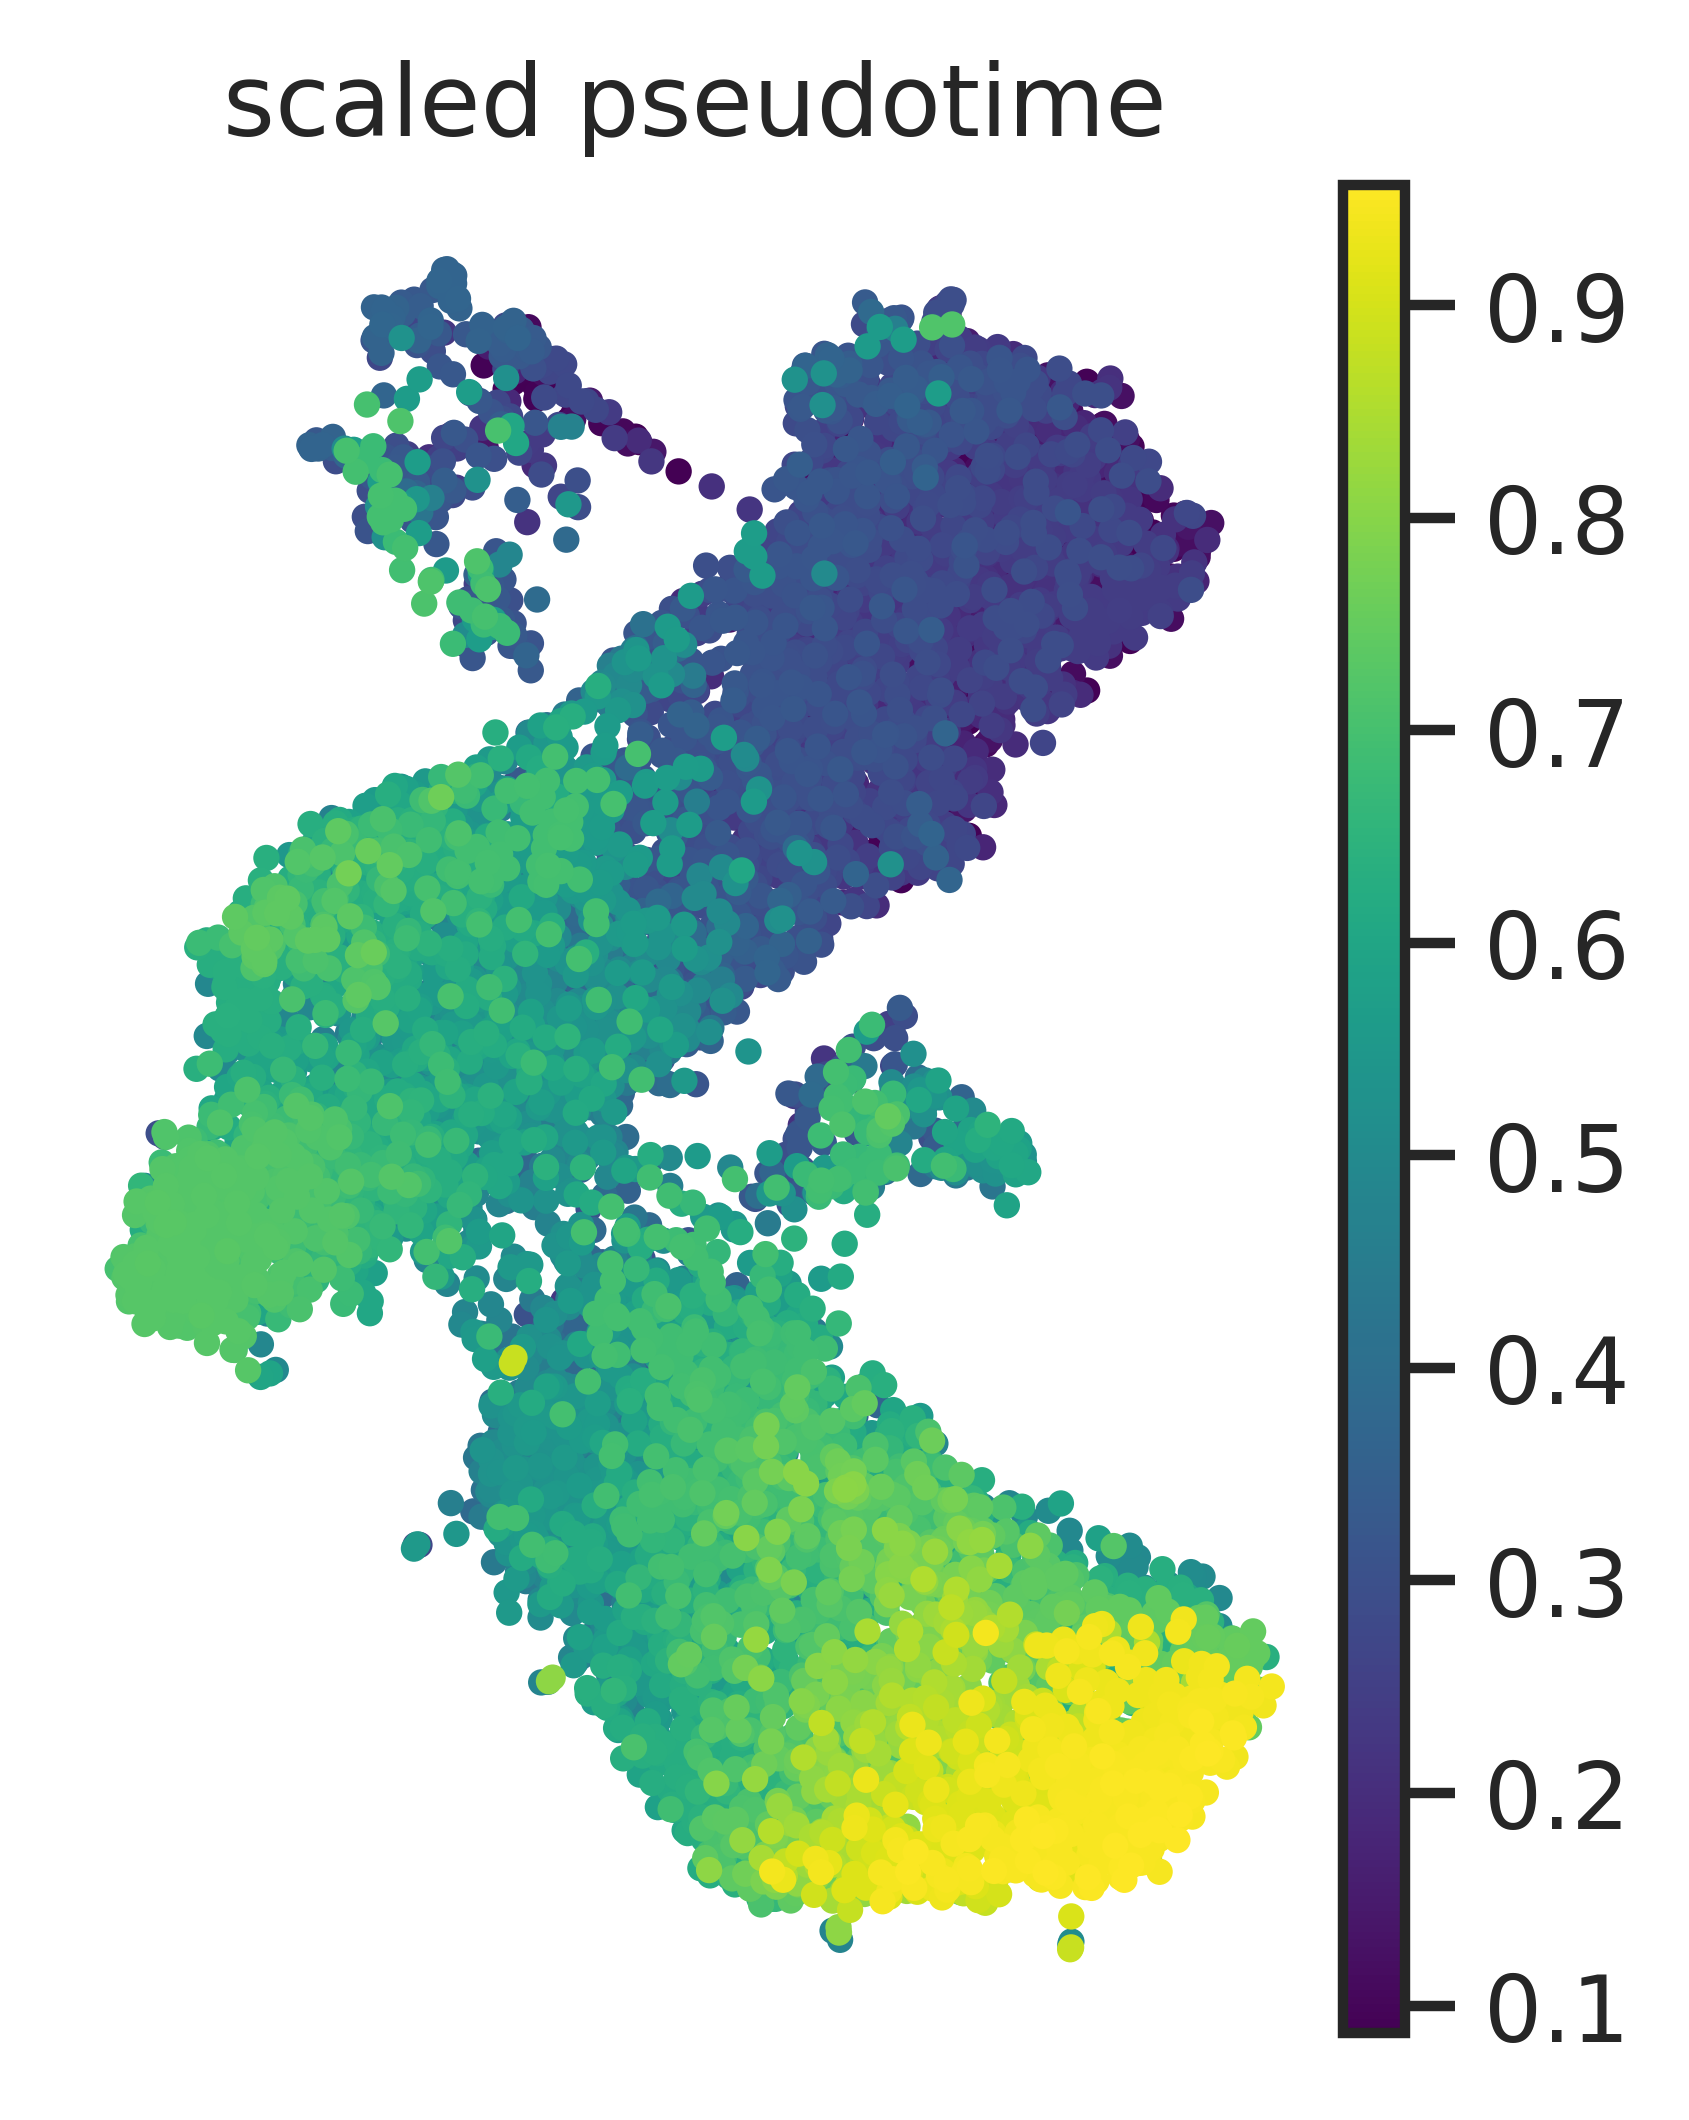

In [266]:
fig, axs = plt.subplots(1,1,figsize=(3,4),dpi=600, frameon=False)
# fig, axs = plt.subplots(figsize=(6,4),dpi=60)

ax = axs
sc.pl.umap(meahr_monocle_plot, color='pseudotime_scaled', cmap='viridis',
           frameon=False, size=40, ax=ax, show=False, 
           title='scaled pseudotime')

# fig.savefig("results/meahr/pseudotime_scaled_umap.pdf")

<Axes: title={'center': 'cell type'}, xlabel='UMAP1', ylabel='UMAP2'>

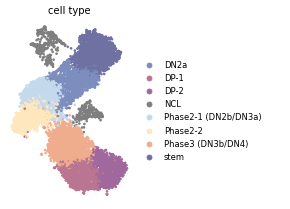

In [137]:
# fig, axs = plt.subplots(1,2,figsize=(6,4),dpi=600, frameon=False)
fig, axs = plt.subplots(1,2,figsize=(6,4),dpi=60)

ax = axs[0]
axs[1].axis("off")
sc.pl.umap(meahr_monocle_plot, color='celltype',
           frameon=False, size=40, ax=ax, show=False, 
           title='cell type')

# fig.savefig("results/meahr/cell_type_umap.pdf")

In [253]:
# Calculate proportions
def compute_proportion(adata, time_key, type_key):
    cell_type_prop = (
        adata.obs
        .groupby(time_key)[type_key]
        .value_counts(normalize=True)
        .mul(100)
        .rename('percentage')
        .reset_index()
    )

    prop_pivot = cell_type_prop.pivot(
        index=time_key,
        columns=type_key,
        values='percentage'
    ).fillna(0)

    return prop_pivot,cell_type_prop

In [ ]:
nbins = 10
pdt_bins = np.linspace(0,1,nbins+1)
pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
meahr_monocle_plot.obs['pseudotime_bin'] = pd.cut(meahr_monocle_plot.obs['pseudotime_scaled'].values, bins=nbins,
                                                    labels = pdt_label)
obs = meahr_monocle_plot.obs.copy()



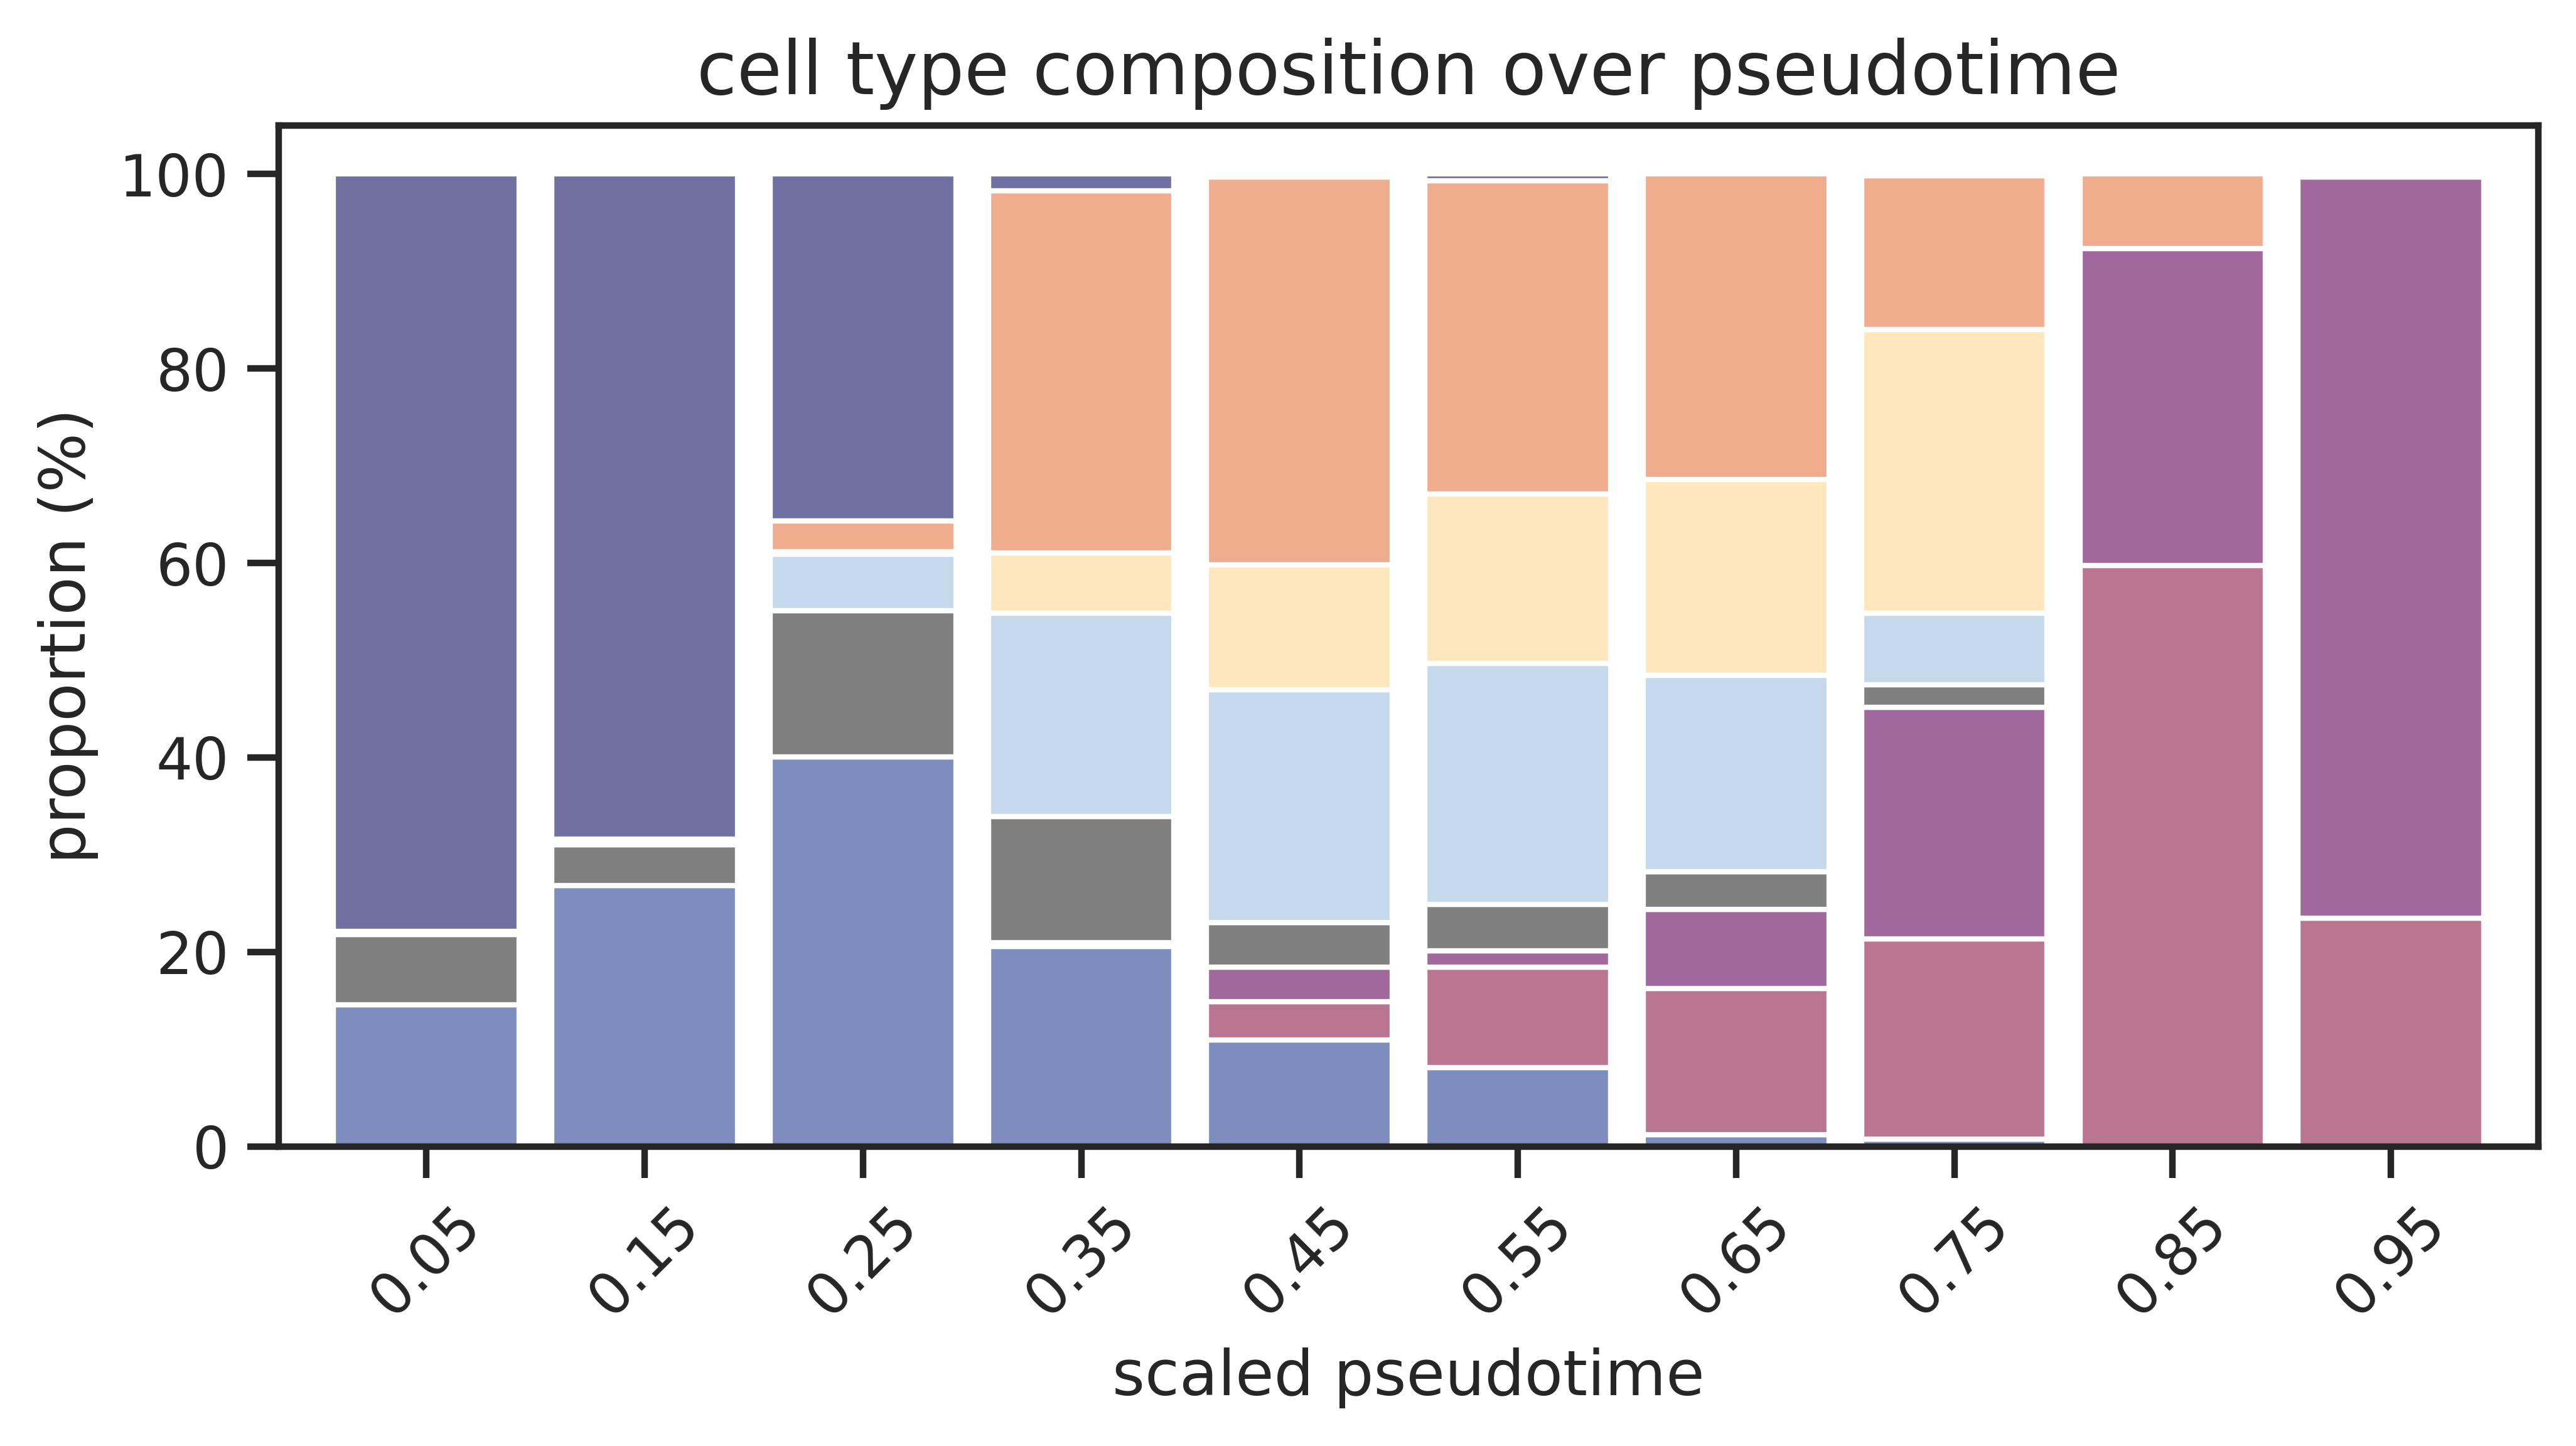

In [287]:
prop_pivot, celltype_pdtbin = compute_proportion(meahr_monocle_plot, 'pseudotime_bin', 'celltype')
prop_pivot.index = pdt_label

plt.figure(figsize=(7, 4), dpi=600, frameon=False)
ax = plt.subplot()

# Get colors from Scanpy (if available)

colors = adata.uns['celltype_colors']

prop_pivot.plot.bar(
    ax=ax,
    stacked=True,
    color=colors,
    width=0.85,       # Bar width
    edgecolor='white' # Optional: adds separation between bars
)



# Format plot
ax.set_xlabel('scaled pseudotime', fontsize=12)
ax.set_ylabel('proportion (%)', fontsize=12)
ax.set_title('cell type composition over pseudotime', fontsize=14)

ax.set_xticks(np.arange(10))
ax.set_xticklabels(np.around(pdt_label, 2).astype(object), rotation=45)

# Move legend outside
plt.legend([], frameon=False)
# plt.legend(
#     title='Cell Types',
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     frameon=False
# )

plt.tight_layout()
plt.show()

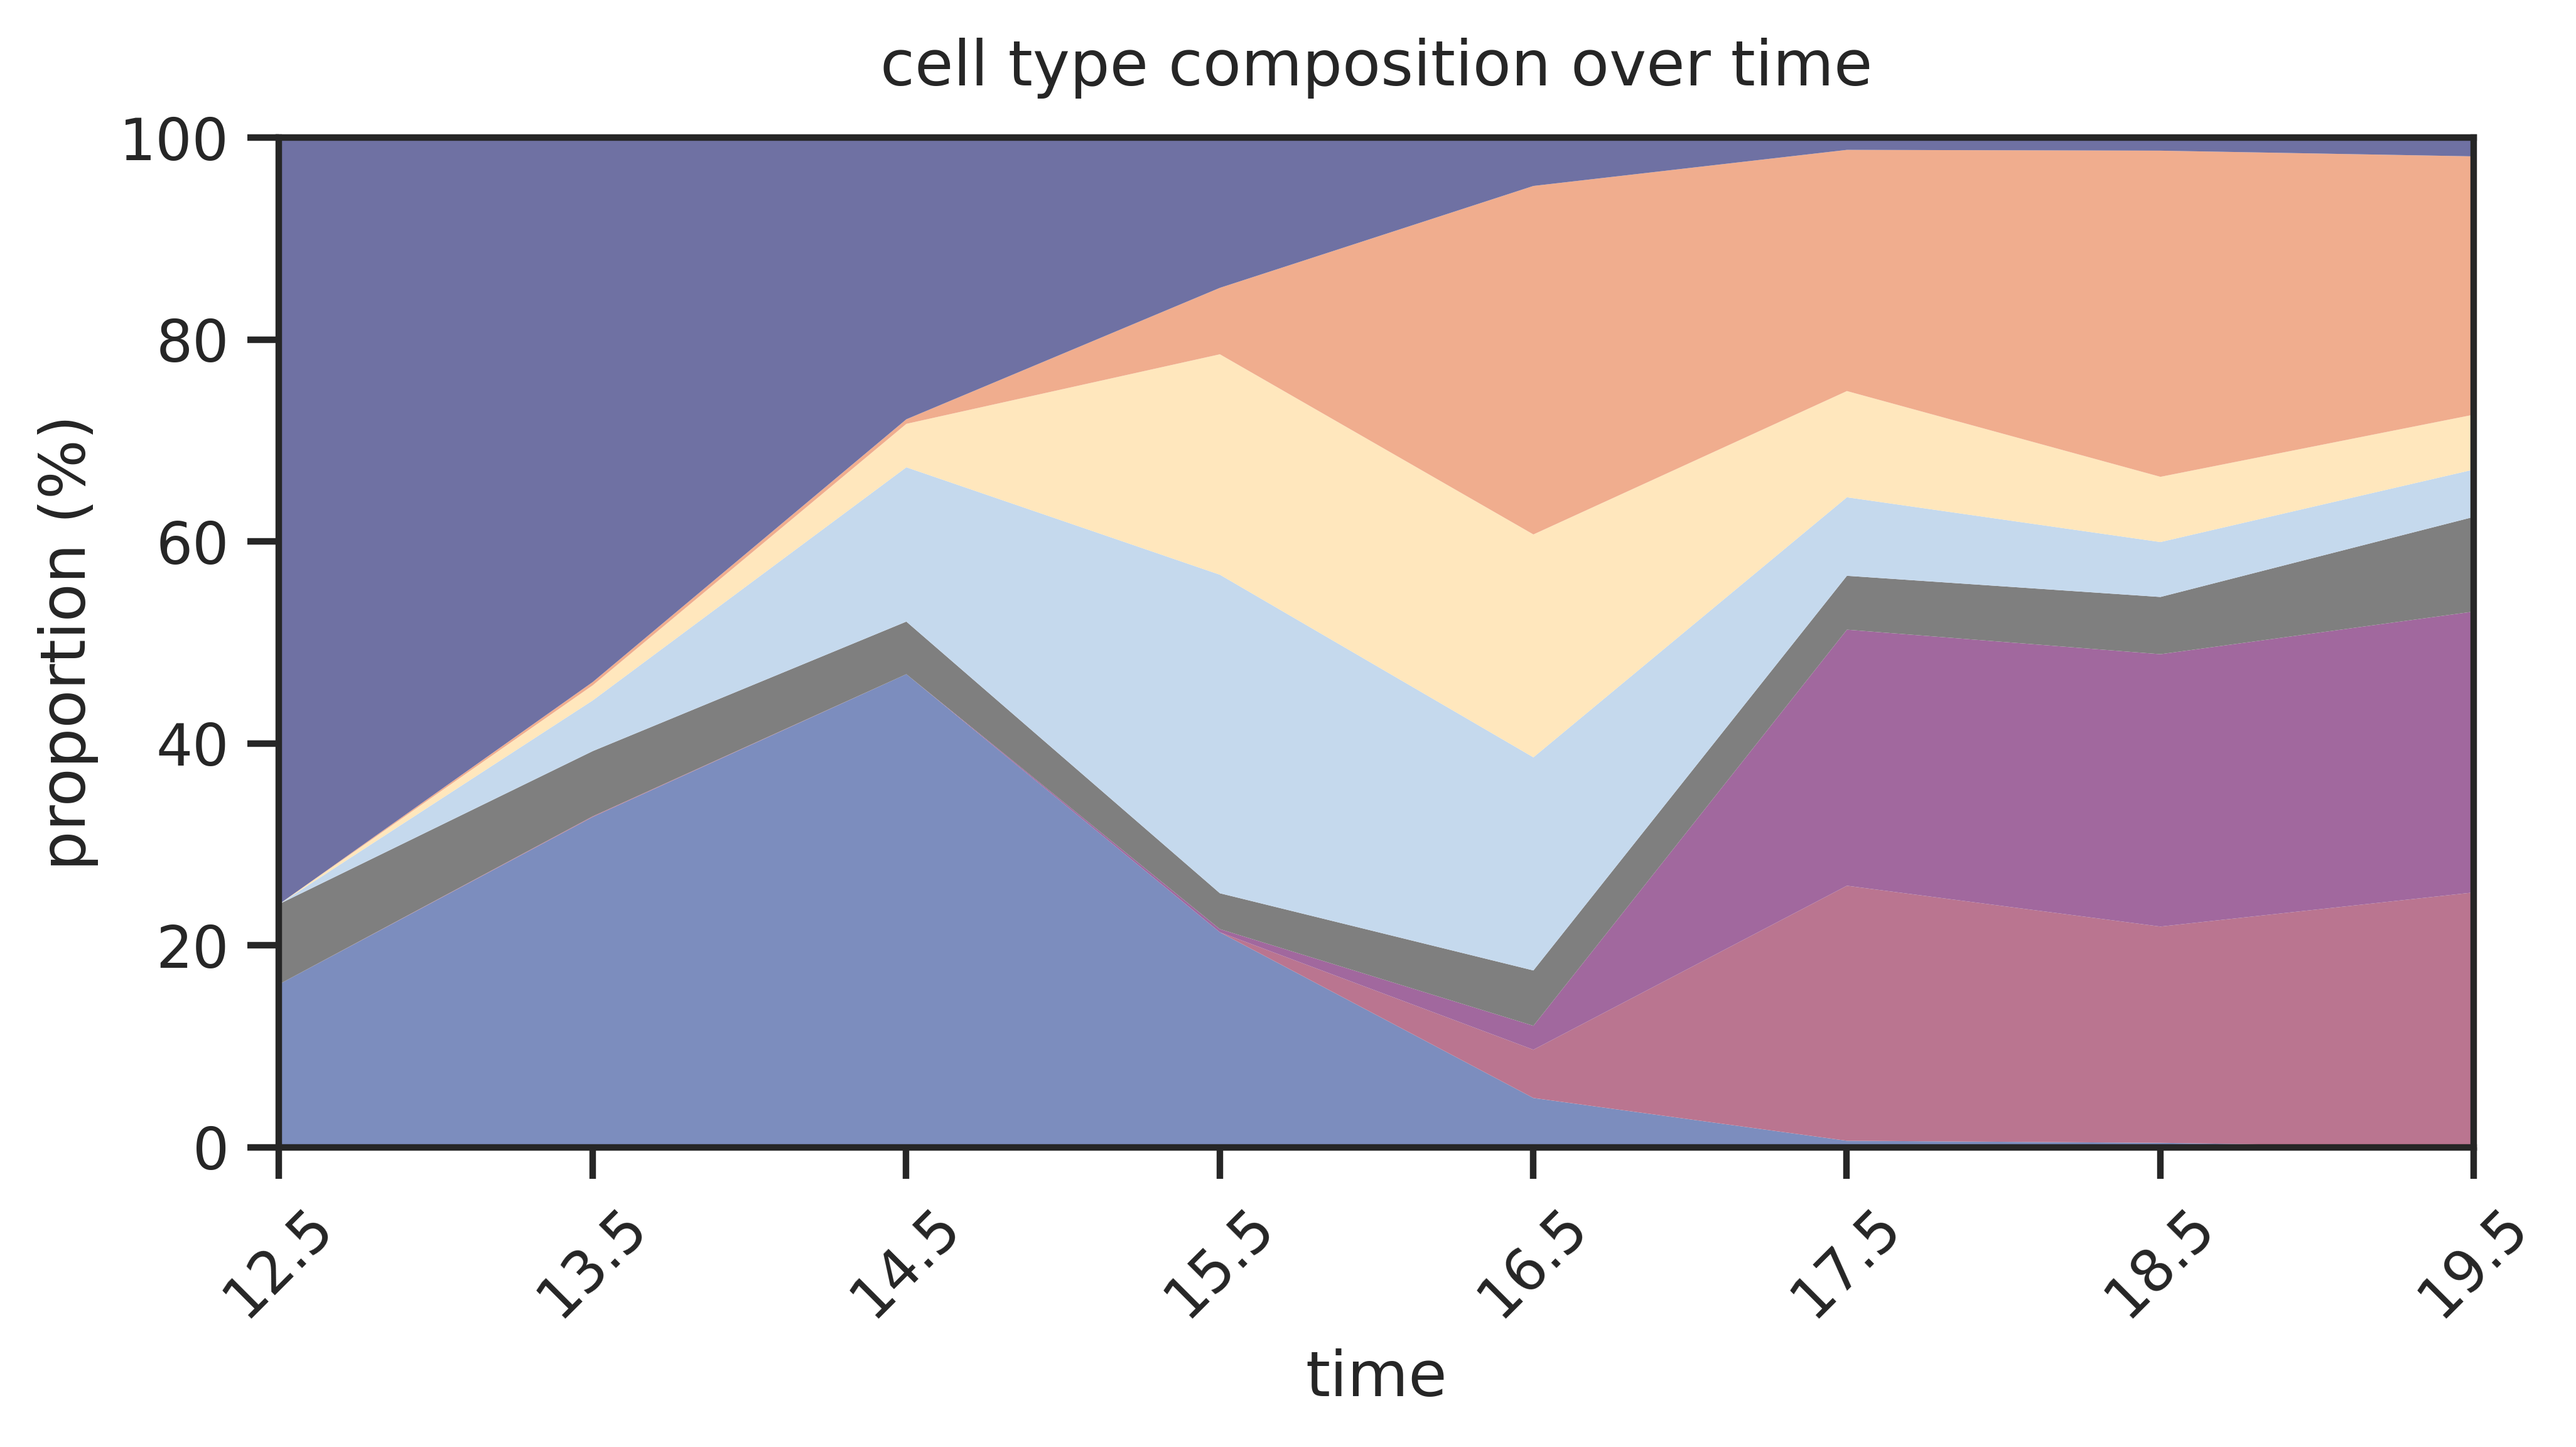

In [284]:
adata=meahr_monocle_plot

# Calculate proportions
prop_pivot, cell_type_prop = compute_proportion(meahr_monocle_plot, 'time', 'celltype')





# Create stacked area plot
sns.set_theme(style="ticks", font_scale=1)
plt.figure(figsize=(5, 3), dpi=600, frameon=False)
ax = plt.subplot()

prop_pivot.plot.area(
    ax=ax,
    stacked=True,
    color=colors,
    linewidth=0
)

# Format plot
ax.set_xlim(12.5,19.5)
ax.set_ylim(0,100)
ax.set_xlabel('time')
ax.set_ylabel('proportion (%)')
ax.set_title('cell type composition over time', pad=10)
ax.set_xticks(adata.uns['pop']['t'])
ax.set_xticklabels(adata.uns['pop']['t'], rotation=45)

plt.legend([], frameon=False)
# plt.legend(
#     title=None,
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     fontsize=9,frameon=False
# )

plt.tight_layout()
plt.show()

In [245]:
fig.savefig("results/meahr/celltype_proportion.svg")

In [30]:
inv_ckpt = np.load('results/meahr/time_inv_ckpt_path.npy', allow_pickle=True).item()
params_inv = np.load('results/meahr/time_inv_params.npy', allow_pickle=True).item()
u_sim_inv = np.load('results/meahr/time_inv_u_simulate.npy', allow_pickle=True).item()
# meahr_monocle.obs_names = np.load('results/meahr/time_inv_meahr_cb.npy', allow_pickle=True)

In [59]:
pdyn_params = pd.read_csv("results/meahr/pdyn_results_meahr_monocle/birth_death_maehr_reg_10.txt", 
                     sep=',', names=['time','g'])
pdyn_g = pdyn_params['g']

## Plotting func

In [76]:
from PINN import pl

def aggregate_params_by_pseudotime(params, param_names='g v2', timepoints=None, adata=meahr_monocle, pseudotime_key='pseudotime_scaled',nbins=100, return_y=True):
    

    pdt_bins = np.linspace(0,1,nbins+1)
    pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
    adata.obs['pseudotime_bin'] = pd.cut(adata.obs[pseudotime_key], bins=nbins,
                                                labels = pdt_label)


    timepoints = adata.uns['pop']['t'] if timepoints is None else timepoints 
    fig, axs = plt.subplots(1, len(timepoints), figsize=(4*len(timepoints)+1,3), gridspec_kw={"wspace":0.4, 'hspace':0.3})
    axs = axs.flatten() if len(timepoints)>1 else [axs]
    
    for i,t in enumerate(timepoints):
        y_col = 'Day%s_'%t + param_names
        data = adata.obs[['pseudotime_bin']]
        data[y_col] = params[i]
        gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()

        x = np.sort(gdata.pseudotime_bin.unique())
        y = gdata[y_col].values

        model2 = np.poly1d(np.polyfit(x, gdata[y_col], 7))

        x_smooth = (x[1:] + x[:-1] )/2
        y_smooth = (y[1:] + y[:-1] )/2

        axs[i].scatter(x_smooth, y_smooth, alpha=0.8)
        axs[i].plot(x, model2(x), color='red', alpha=0.4)
    if return_y:
        return y_smooth
    else:
        return fig, axs

In [13]:
meahr_monocle.uns['pop']['t'][[0]]

array([12.5])

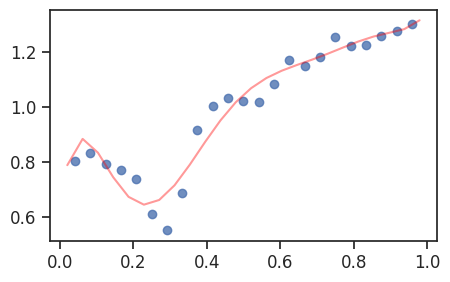

In [289]:
nbins = 23
y =  aggregate_params_by_pseudotime(params_inv[f'g_v3'][[0]], param_names='g_v1',
                                   timepoints=meahr_monocle.uns['pop']['t'][[0]],
                                    pseudotime_key='pseudotime_scaled', 
                                    adata=meahr_monocle, nbins=nbins+1, return_y=True)


x_knots = torch.linspace(0,1,nbins)
y_knots = torch.from_numpy(y)

g_cs = models.CubicSpline(x=x_knots, y=y_knots)

g_smooth = g_cs(torch.linspace(0,1,300),None).detach().numpy()
g_smooth = (g_smooth[:-1] + g_smooth[1:])/2
        

Text(0, 0.5, 'pseudodynamics \nvalues')

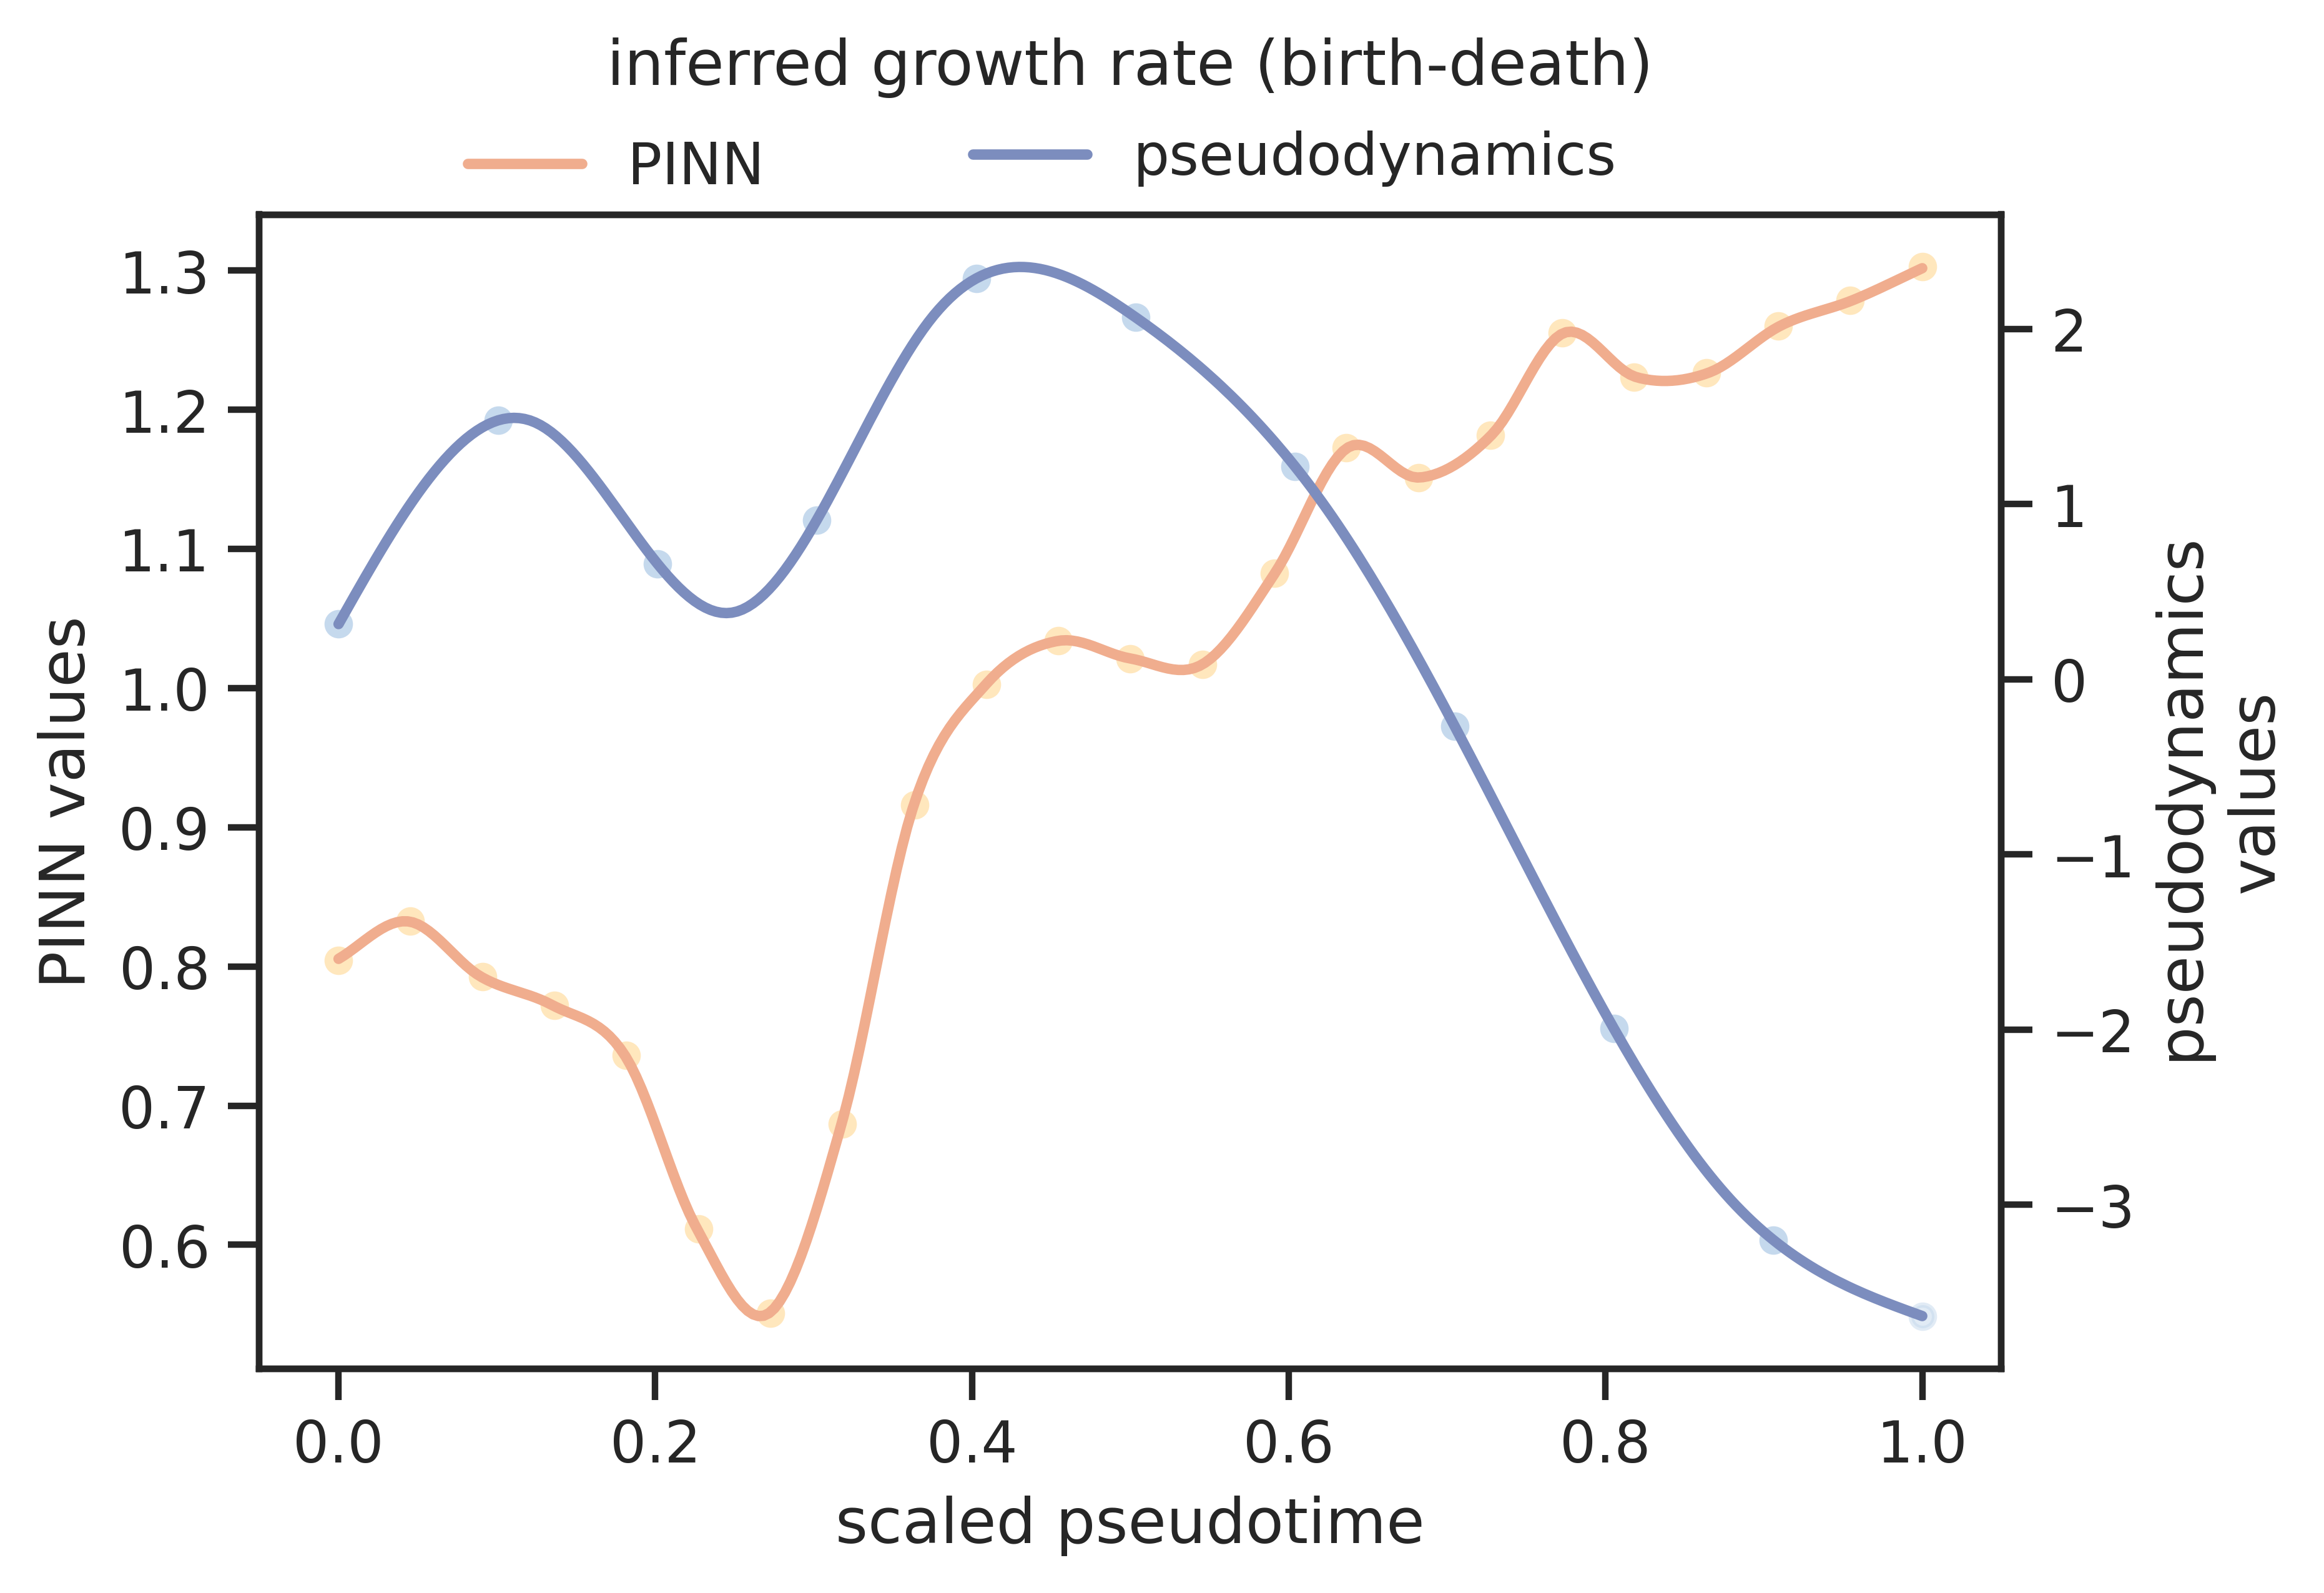

In [ ]:
sns.set_theme(style="ticks", font_scale=1)
fig = plt.figure(figsize=(6,4), dpi=600)
ax1 = fig.gca()
ax2 = ax1.twinx()  

ax1.scatter(np.linspace(0,1,nbins), y, color='#FFE7BD', s=20)
ax2.scatter(np.linspace(0,1,299)[np.arange(0,299,30)], pdyn_g[np.arange(0,299,30)],  s=20, color='#C5D9ED')
ax2.scatter(np.linspace(0,1,299)[-1], pdyn_g.values[-1], alpha=0.5, s=20, color='#C5D9ED')

ax2.plot(np.linspace(0,1,299), pdyn_g, label='pseudodynamics', color='#7C8DBE', linewidth=2)
ax1.plot(np.linspace(0,1,299), g_smooth, label='PINN ',color="#F0AD8E", linewidth=2)

ax1.legend(bbox_to_anchor=[0.13,1.1, 0.2,0.01], frameon=False)
ax2.legend(bbox_to_anchor=[0.38,0.98, 0.2,0.01], frameon=False)

ax1.set_title('inferred growth rate (birth-death)', pad=25)
ax1.set_xlabel('scaled pseudotime')
ax1.set_ylabel('PINN values ')
ax2.set_ylabel('pseudodynamics \nvalues')


In [47]:
g_smooth

array([0.82121277, 0.8174178 , 0.81304824, 0.808286  , 0.80331373,
       0.7983136 , 0.79346794, 0.788959  , 0.7849691 , 0.78168064,
       0.77927566, 0.77793676, 0.77784604, 0.7793515 , 0.7832162 ,
       0.7890992 , 0.7965174 , 0.80498767, 0.81402725, 0.8231531 ,
       0.8318822 , 0.8397314 , 0.8462181 , 0.850859  , 0.853171  ,
       0.8526676 , 0.84847516, 0.84071445, 0.8301413 , 0.8175114 ,
       0.8035803 , 0.78910375, 0.77483714, 0.7615364 , 0.74995714,
       0.74085504, 0.73498577, 0.7331048 , 0.73622864, 0.74524355,
       0.7591147 , 0.77666867, 0.7967314 , 0.8181291 , 0.8396884 ,
       0.8602353 , 0.878596  , 0.8935967 , 0.9040639 , 0.9088236 ,
       0.90670335, 0.8971198 , 0.8810146 , 0.85957205, 0.8339765 ,
       0.8054125 , 0.77506435, 0.7441167 , 0.7137535 , 0.68515974,
       0.6595194 , 0.63801694, 0.6218371 , 0.61169755, 0.6064788 ,
       0.605278  , 0.6072426 , 0.6115196 , 0.61725664, 0.62360096,
       0.6297    , 0.634701  , 0.63775134, 0.63799846, 0.63458